# Notebook 2 — Exploratory Data Analysis & Data Visualization

### Objectives
- Univariate analysis: distributions of all feature groups
- Bivariate analysis: feature relationships with `cons_quint`
- Multivariate analysis: correlations, region × settlement interactions
- Temporal trend analysis: wealth and asset ownership evolution across waves
- Hypothesis testing: statistical significance of key group differences
- Outlier detection: IQR method + Z-score 


## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from data_cleaner import DataCleaner
from feature_enginner import FeatureEngineer

sns.set_theme(style='whitegrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.3f}'.format)
COLORS5 = ['#d32f2f','#f57c00','#fbc02d','#388e3c','#1565c0']
Q_LABELS = {1:'Q1 Poorest',2:'Q2',3:'Q3',4:'Q4',5:'Q5 Richest'}
print("✓ Setup complete")


✓ Setup complete


## 2. Load & Clean Data

In [3]:
df_raw  = pd.read_csv('../data/processed/all_waves_merged.csv')
cleaner = DataCleaner()
df_clean= cleaner.fit_transform(df_raw)
fe      = FeatureEngineer()
df      = fe.engineer_all(df_clean)

print(f"Raw:     {df_raw.shape}")
print(f"Cleaned: {df_clean.shape}")
print(f"After FE:{df.shape}  (+{len(fe.created_features_)} engineered features)")
print("\nCleaning log:")
cleaner.report()


Raw:     (25914, 46)
Cleaned: (25349, 44)
After FE:(25349, 65)  (+21 engineered features)

Cleaning log:


,step,rows_dropped,rows_remaining,nulls_filled,nulls_remaining,values_capped,method,flags,dropped
0,drop_missing_target,565.000,25349.000,NaN,NaN,NaN,NaN,NaN,NaN
1,impute_missing,NaN,NaN,171779.000,0.000,NaN,NaN,NaN,NaN
2,handle_outliers,NaN,NaN,NaN,NaN,6508.000,IQR×3.0 per wave,NaN,NaN
3,add_coverage_flags,NaN,NaN,NaN,NaN,NaN,NaN,"[has_full_housing, has_enterprise_data]",NaN
4,drop_zero_variance,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[is_tigray_conflict]
5,drop_identifier_columns,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[household_id_w1]


## 3. Descriptive Statistics (describe_data)

In [ ]:
# Numeric summary - describe_data
print("── Numeric Summary ─────────────────────────────────────────────")
desc = cleaner.describe_data(df)
desc


── Numeric Summary ─────────────────────────────────────────────


,wave,settlement,zone_id,hh_size,adulteq,survey_weight,cons_quint,head_sex,head_age,head_age_sq,is_female_headed,head_edu_level,head_literate,hh_any_wage_earner,hh_n_workers,hh_avg_weeks_worked,has_nonfarm_enterprise,enterprise_asset_count,rooms,roof,wall,floor,water,toilet,fuel,has_electricity,owns_phone,owns_tv,owns_fridge,asset_count,...,experienced_illness,experienced_death,experienced_crop_loss,log_hh_size,dependency_ratio,assets_per_member,post_covid,has_full_housing,has_enterprise_data,adults_ratio,is_large_hh,is_single_person,roof_quality,floor_quality,improved_water,improved_sanitation,clean_fuel,housing_quality_idx,modern_asset_score,has_any_modern_asset,labour_intensity,is_fully_dependent,shock_breadth,is_multi_shock,is_urban,is_addis,is_peripheral,head_prime_working_age,head_elderly,educated_prime_head
count,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,...,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000,25349.000
mean,3.156,0.974,16080.562,4.546,3.713,3499.143,3.356,0.697,44.283,2195.858,0.303,1.746,0.741,0.343,0.460,541.900,0.094,0.330,7.173,1.441,1.907,2.492,1.373,2.901,6.033,0.053,0.011,0.056,0.052,0.119,...,0.149,0.062,0.052,1.616,0.176,0.033,0.196,0.537,0.537,0.824,0.198,0.093,0.913,0.073,0.920,0.901,0.119,0.585,0.279,0.108,0.123,0.657,0.316,0.054,0.268,0.077,0.210,0.714,0.185,0.194
std,1.353,0.848,20137.073,2.348,1.932,4264.608,1.438,0.460,15.307,1534.393,0.460,1.263,0.438,0.475,0.849,7588.424,0.291,1.064,10.290,0.951,2.749,1.238,1.279,1.239,2.202,0.225,0.104,0.231,0.222,0.359,...,0.356,0.241,0.221,0.456,0.088,0.130,0.397,0.499,0.499,0.088,0.399,0.291,0.173,0.238,0.272,0.299,0.324,0.101,0.855,0.310,0.239,0.475,0.596,0.226,0.443,0.266,0.407,0.452,0.389,0.395
min,1.000,0.000,101.000,1.000,0.740,4.389,1.000,0.000,3.000,9.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,1.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,0.693,0.000,0.000,0.000,0.000,0.000,0.476,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,2.000,0.000,1406.000,3.000,2.300,593.941,2.000,0.000,32.000,1024.000,0.000,1.000,0.000,0.000,0.000,14.000,0.000,0.000,0.000,1.000,1.000,1.000,1.000,3.000,5.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,1.386,0.112,0.000,0.000,0.000,0.000,0.760,0.000,0.000,0.800,0.000,1.000,1.000,0.000,0.560,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
50%,3.000,1.000,7100.000,4.000,3.490,1928.978,4.000,1.000,41.000,1681.000,0.000,1.000,1.000,0.000,0.000,19.000,0.000,0.000,4.000,1.000,1.000,3.000,1.000,3.000,5.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,1.609,0.180,0.000,0.000,1.000,1.000,0.820,0.000,0.000,1.000,0.000,1.000,1.000,0.000,0.600,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,1.000,0.000,0.000
75%,4.000,1.000,20203.000,6.000,4.920,4963.711,5.000,1.000,55.000,3025.000,1.000,3.000,1.000,1.000,1.000,28.000,0.000,0.000,8.000,2.000,1.000,3.000,1.000,3.000,8.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.000,1.946,0.240,0.000,0.000,1.000,1.000,0.888,0.000,0.000,1.000,0.000,1.000,1.000,0.000,0.600,0.000,0.000,0.167,1.000,1.000,0.000,1.000,0.000,0.000,1.000,0.000,0.000
max,5.000,3.000,72005.000,19.000,14.440,32753.236,5.000,1.000,100.000,10000.000,1.000,8.000,1.000,1.000,4.000,975000.000,1.000,8.000,63.000,51.000,18.000,18.000,10.000,8.000,15.000,1.000,1.000,1.000,1.000,3.000,...,1.000,1.000,1.000,2.996,0.524,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000

In [ ]:
# Frequency table for target variable (stb.freq)
print("── Target Frequency (cons_quint) ───────────────────────────────")
freq = df['cons_quint'].value_counts().sort_index().reset_index()
freq.columns = ['cons_quint','count']
freq['pct'] = (freq['count'] / len(df) * 100).round(2)
freq['cumulative_pct'] = freq['pct'].cumsum().round(2)
freq['label'] = freq['cons_quint'].map(Q_LABELS)
print(freq.to_string(index=False))


── Target Frequency (cons_quint) ───────────────────────────────
 cons_quint  count    pct  cumulative_pct      label
      1.000   3886 15.330          15.330 Q1 Poorest
      2.000   3937 15.530          30.860         Q2
      3.000   4482 17.680          48.540         Q3
      4.000   5354 21.120          69.660         Q4
      5.000   7690 30.340         100.000 Q5 Richest


## 4. Univariate Analysis - Continuous Features
histograms, density plots, box plots for distribution understanding.


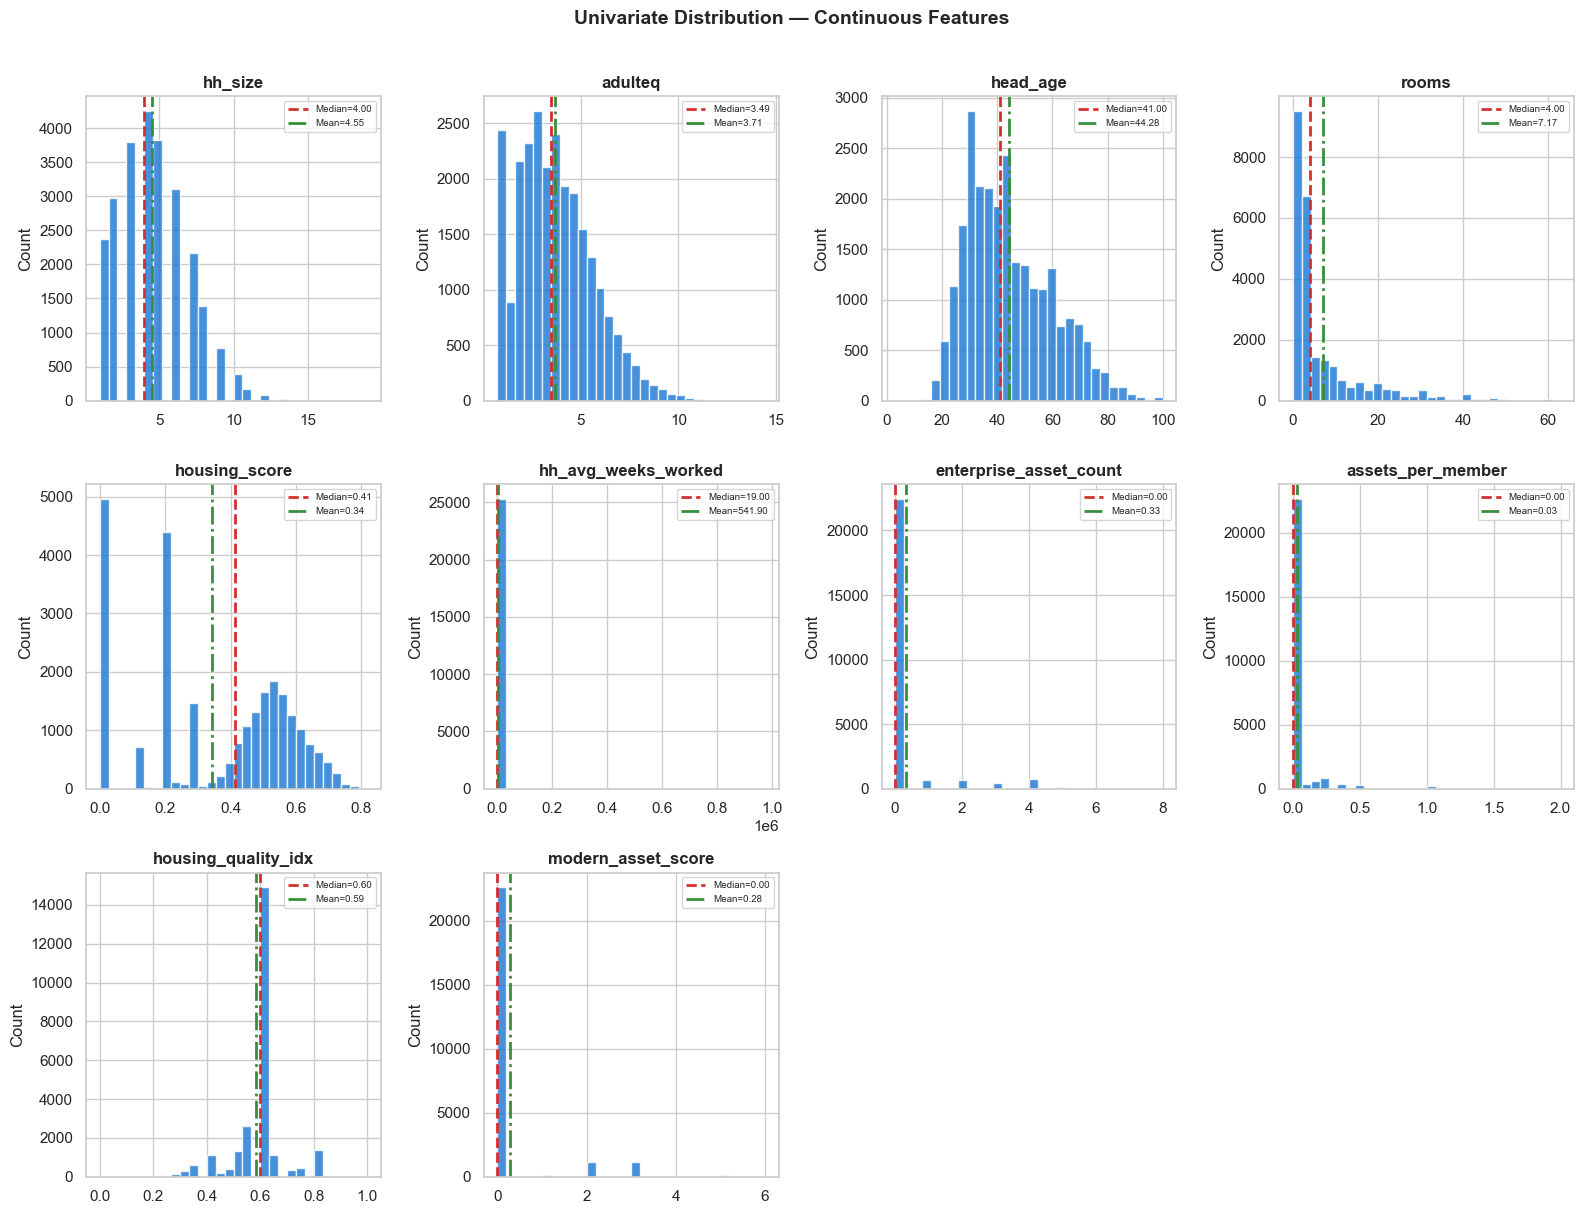

In [6]:
cont_cols = ['hh_size','adulteq','head_age','rooms','housing_score',
             'hh_avg_weeks_worked','enterprise_asset_count',
             'assets_per_member','housing_quality_idx','modern_asset_score']
cont_cols = [c for c in cont_cols if c in df.columns]

n_cols = 4
n_rows = -(-len(cont_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.ravel()

for i, col in enumerate(cont_cols):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=30, color='#1976D2', edgecolor='white', alpha=0.8)
    ax.axvline(data.median(), color='#d32f2f', lw=2, ls='--',
               label=f'Median={data.median():.2f}')
    ax.axvline(data.mean(), color='#388e3c', lw=2, ls='-.',
               label=f'Mean={data.mean():.2f}')
    ax.set_title(col, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_ylabel('Count')

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Univariate Distribution — Continuous Features', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/univariate_continuous.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Univariate Analysis - Binary & Ordinal Features

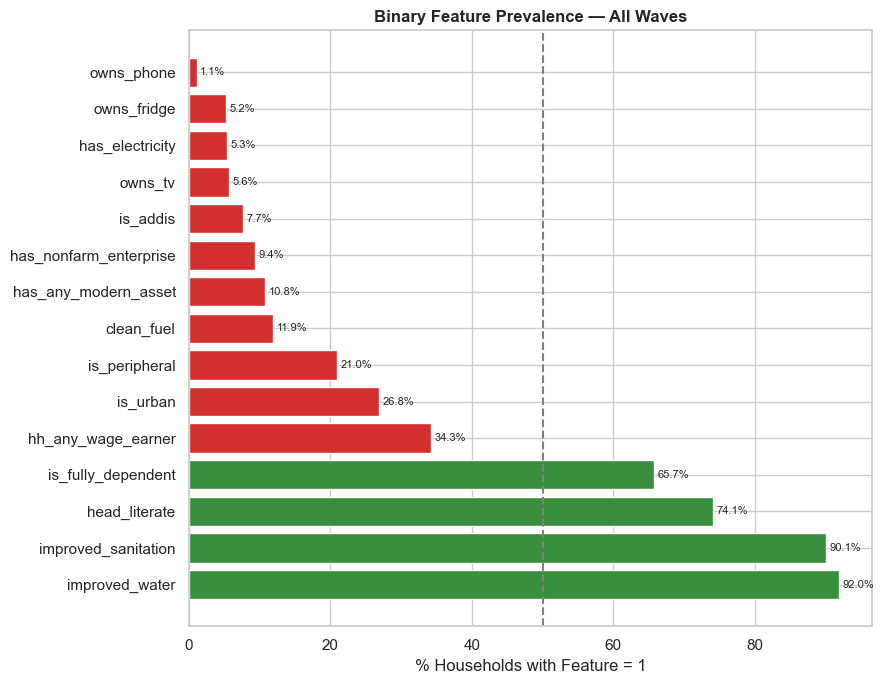

In [7]:
binary_cols = ['owns_phone','owns_tv','owns_fridge','has_electricity',
               'hh_any_wage_earner','has_nonfarm_enterprise',
               'improved_water','improved_sanitation','clean_fuel',
               'is_urban','is_addis','is_peripheral','head_literate',
               'has_any_modern_asset','is_fully_dependent']
binary_cols = [c for c in binary_cols if c in df.columns]

prevalence = (df[binary_cols].mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
clr = ['#388e3c' if v >= 50 else '#d32f2f' for v in prevalence.values]
ax.barh(prevalence.index, prevalence.values, color=clr, edgecolor='white')
ax.axvline(50, color='grey', lw=1.5, ls='--', label='50% line')
ax.set_xlabel('% Households with Feature = 1')
ax.set_title('Binary Feature Prevalence — All Waves', fontweight='bold')
for i, v in enumerate(prevalence.values):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/binary_prevalence.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Bivariate Analysis - Features vs Wealth Quintile
Box plots by quintile reveal how each feature distributes across wealth levels.
bivariate analysis, groupby statistics.


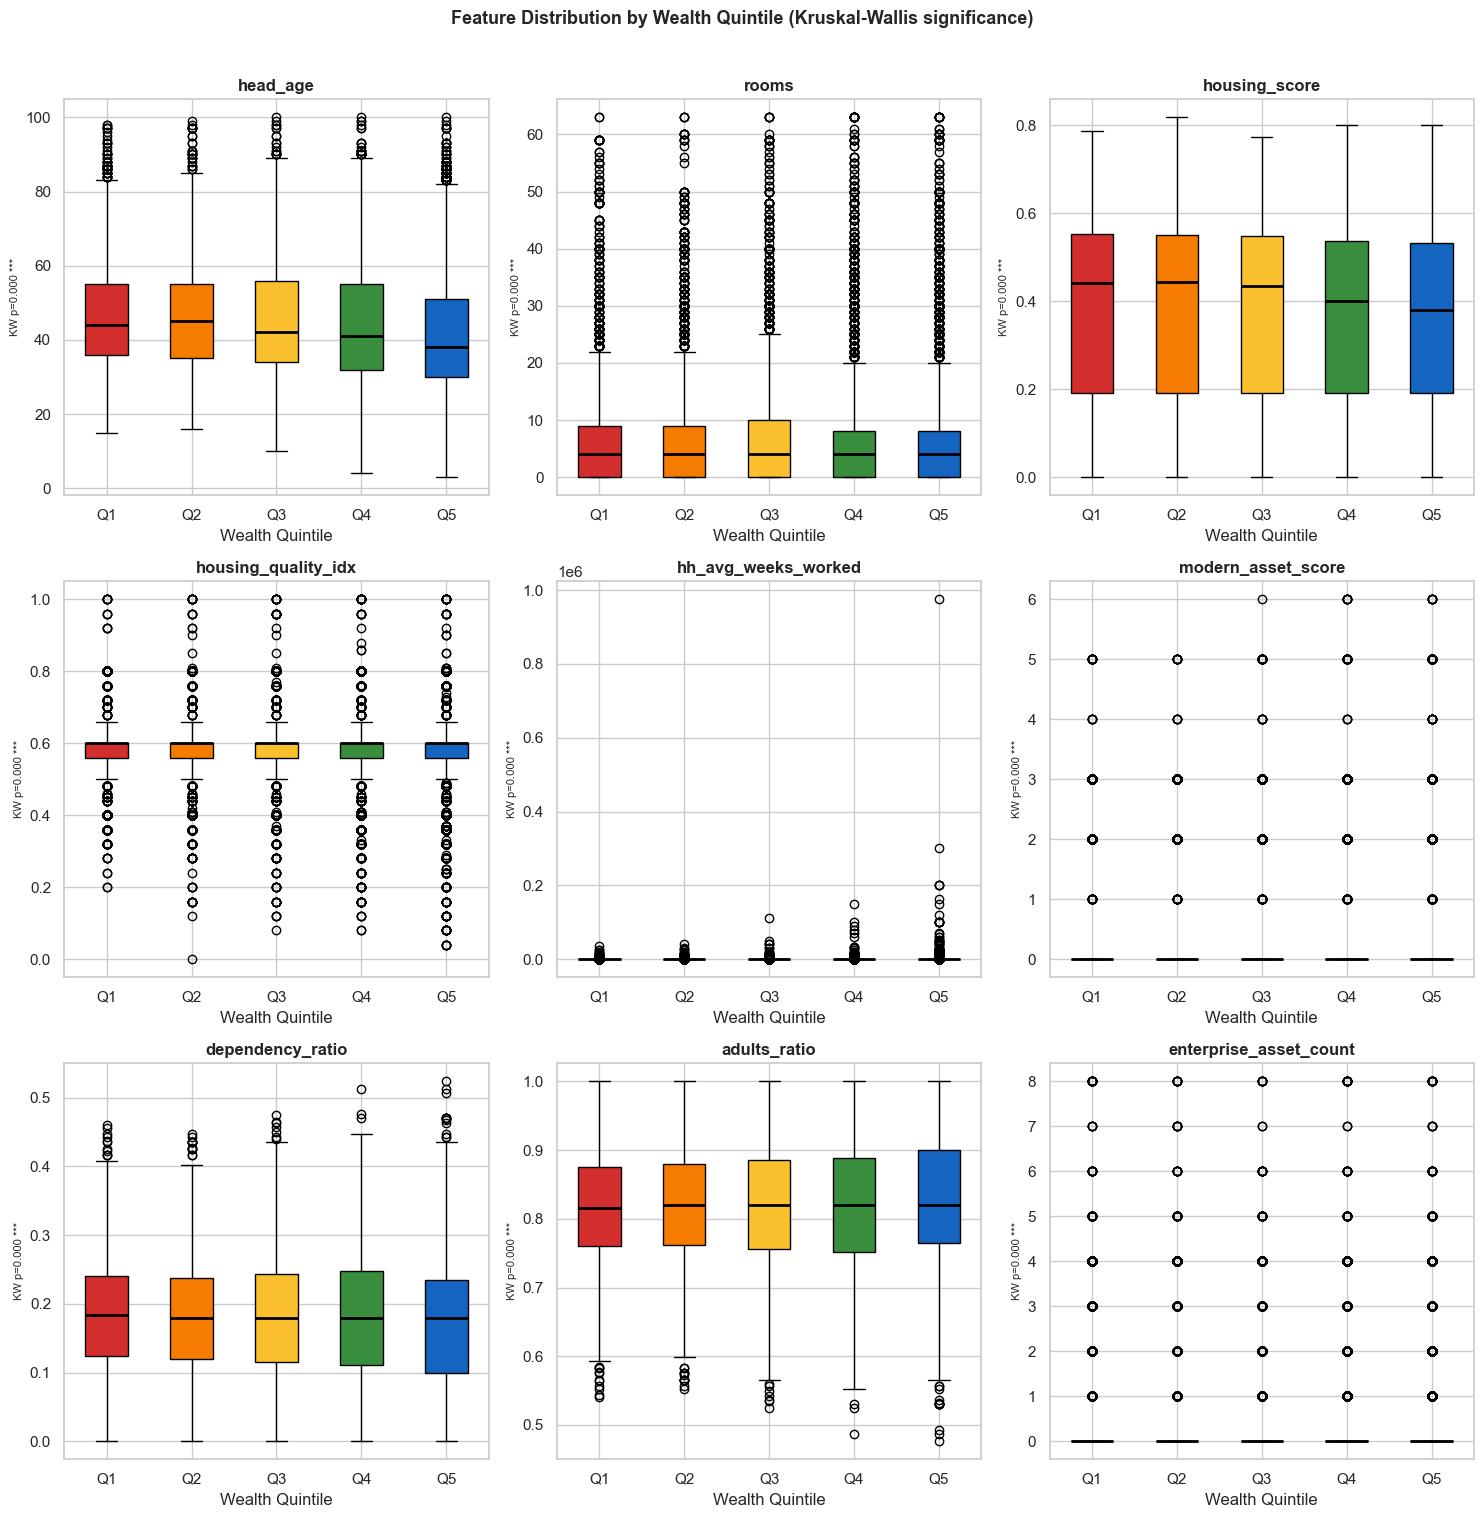

In [8]:
key_cont = ['head_age','rooms','housing_score','housing_quality_idx',
            'hh_avg_weeks_worked','modern_asset_score',
            'dependency_ratio','adults_ratio','enterprise_asset_count']
key_cont = [c for c in key_cont if c in df.columns]

n_cols = 3
n_rows = -(-len(key_cont) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(key_cont):
    ax = axes[i]
    groups = [df.loc[df['cons_quint']==q, col].dropna() for q in range(1,6)]
    bplot = ax.boxplot(groups, patch_artist=True, notch=False,
                       medianprops=dict(color='black', lw=2))
    for patch, c in zip(bplot['boxes'], COLORS5):
        patch.set_facecolor(c)
    ax.set_xticklabels(['Q1','Q2','Q3','Q4','Q5'])
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Wealth Quintile')

    # Kruskal-Wallis test (non-parametric ANOVA)
    stat, p = stats.kruskal(*groups)
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
    ax.set_ylabel(f'KW p={p:.3f} {sig}', fontsize=8)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distribution by Wealth Quintile (Kruskal-Wallis significance)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/bivariate_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()


### 6.1 Asset Ownership Rate by Quintile

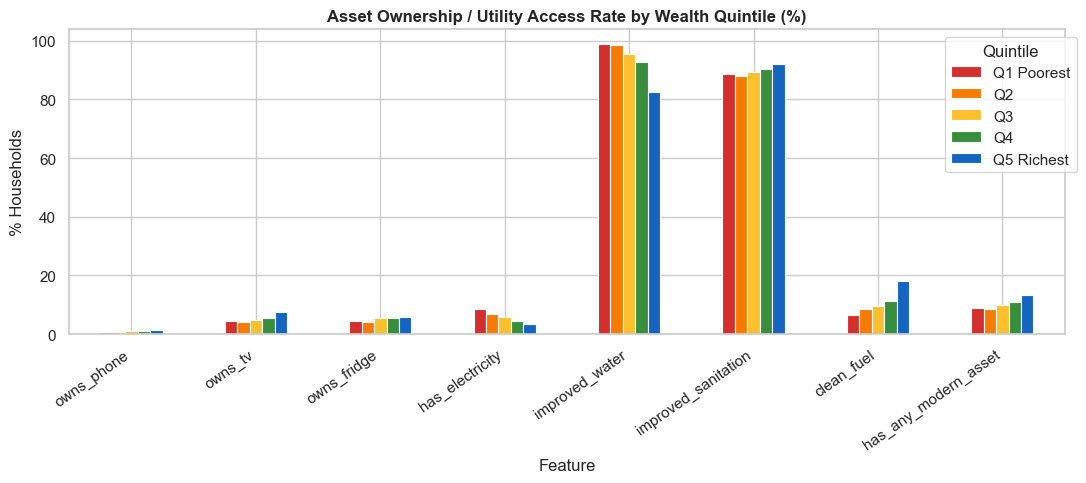

In [9]:
asset_cols = ['owns_phone','owns_tv','owns_fridge','has_electricity',
              'improved_water','improved_sanitation','clean_fuel',
              'has_any_modern_asset']
asset_cols = [c for c in asset_cols if c in df.columns]

pivot_asset = (df.groupby('cons_quint')[asset_cols]
                 .mean().multiply(100).round(1))

fig, ax = plt.subplots(figsize=(11, 5))
pivot_asset.T.plot(kind='bar', ax=ax, color=COLORS5, edgecolor='white',
                   linewidth=0.8)
ax.set_title('Asset Ownership / Utility Access Rate by Wealth Quintile (%)',
             fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('% Households')
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
ax.legend(title='Quintile',
          labels=[Q_LABELS[i] for i in range(1,6)],
          bbox_to_anchor=(1.02,1))
plt.tight_layout()
plt.savefig('../reports/asset_by_quintile.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Correlation Analysis - Multivariate
Pearson correlation heatmap for numeric features. multivariate analysis.


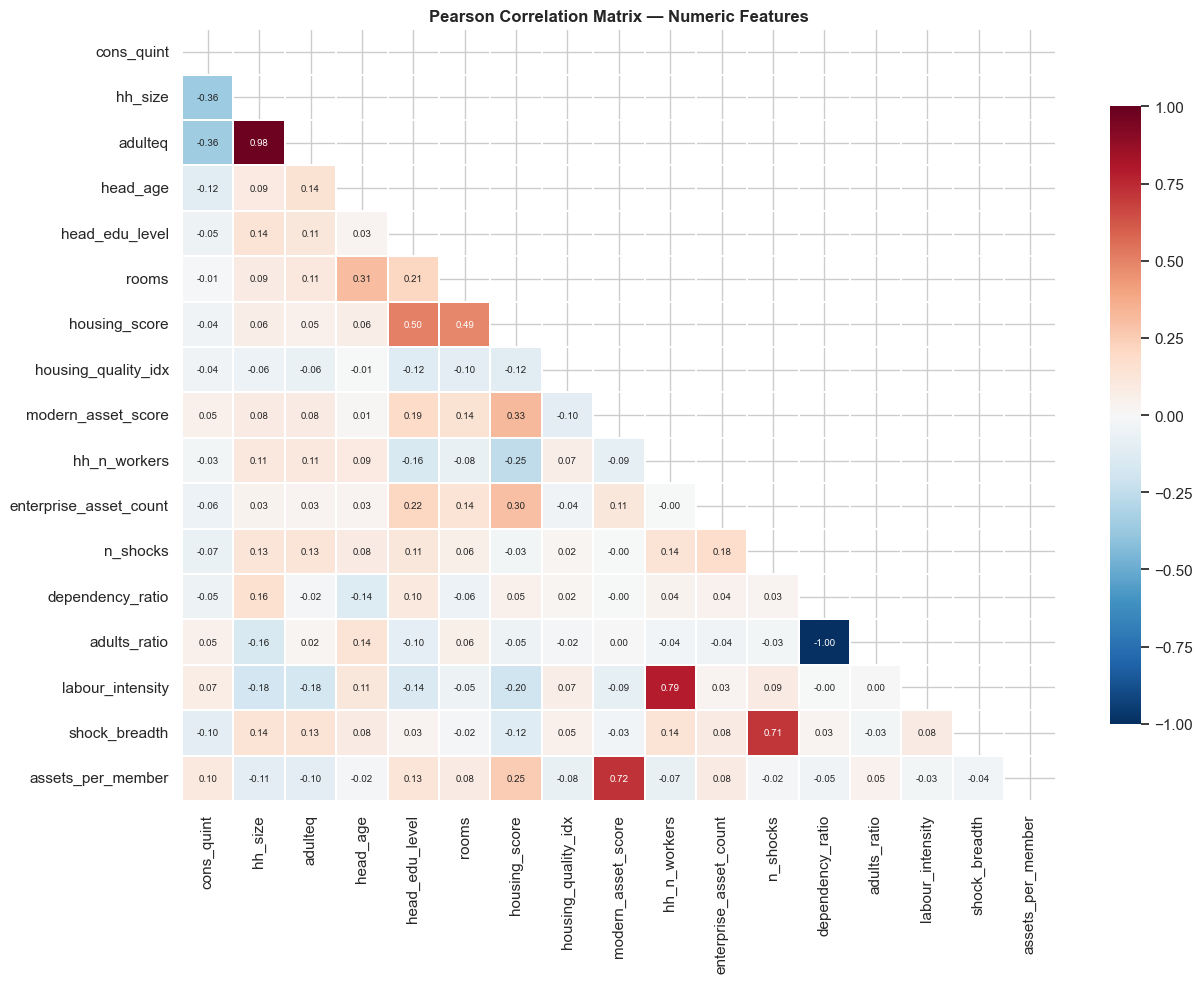


── Top correlations with cons_quint ──────────────────────────
hh_size                  0.362
adulteq                  0.359
head_age                 0.117
shock_breadth            0.104
assets_per_member        0.101
labour_intensity         0.071
n_shocks                 0.069
enterprise_asset_count   0.055
modern_asset_score       0.054
dependency_ratio         0.050
adults_ratio             0.050
head_edu_level           0.049


In [10]:
num_cols = ['cons_quint','hh_size','adulteq','head_age','head_edu_level',
            'rooms','housing_score','housing_quality_idx','modern_asset_score',
            'hh_n_workers','enterprise_asset_count','n_shocks',
            'dependency_ratio','adults_ratio','labour_intensity',
            'shock_breadth','assets_per_member']
num_cols = [c for c in num_cols if c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':7},
            linewidths=0.3, ax=ax, cbar_kws={'shrink':0.8})
ax.set_title('Pearson Correlation Matrix — Numeric Features', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
print("\n── Top correlations with cons_quint ──────────────────────────")
top_corr = corr['cons_quint'].drop('cons_quint').abs().sort_values(ascending=False)
print(top_corr.head(12).to_string())


## 8. Geographic Patterns - Region × Settlement Heatmap

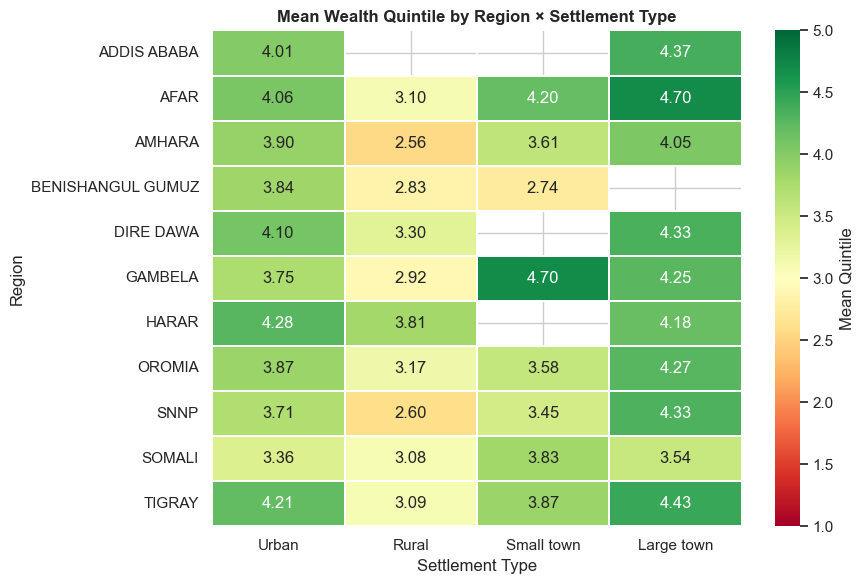

In [11]:
pivot = (df.groupby(['region','settlement'], observed=True)['cons_quint']
           .mean().unstack()
           .rename(columns={0:'Urban',1:'Rural',2:'Small town',3:'Large town'}))

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=1, vmax=5, linewidths=0.3, ax=ax,
            cbar_kws={'label':'Mean Quintile'})
ax.set_title('Mean Wealth Quintile by Region × Settlement Type',
             fontweight='bold')
ax.set_xlabel('Settlement Type'); ax.set_ylabel('Region')
plt.tight_layout()
plt.savefig('../reports/region_settlement_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Temporal Trend Analysis (Waves 1 - 5)
Temporal analysis - how key welfare indicators evolved across survey rounds.


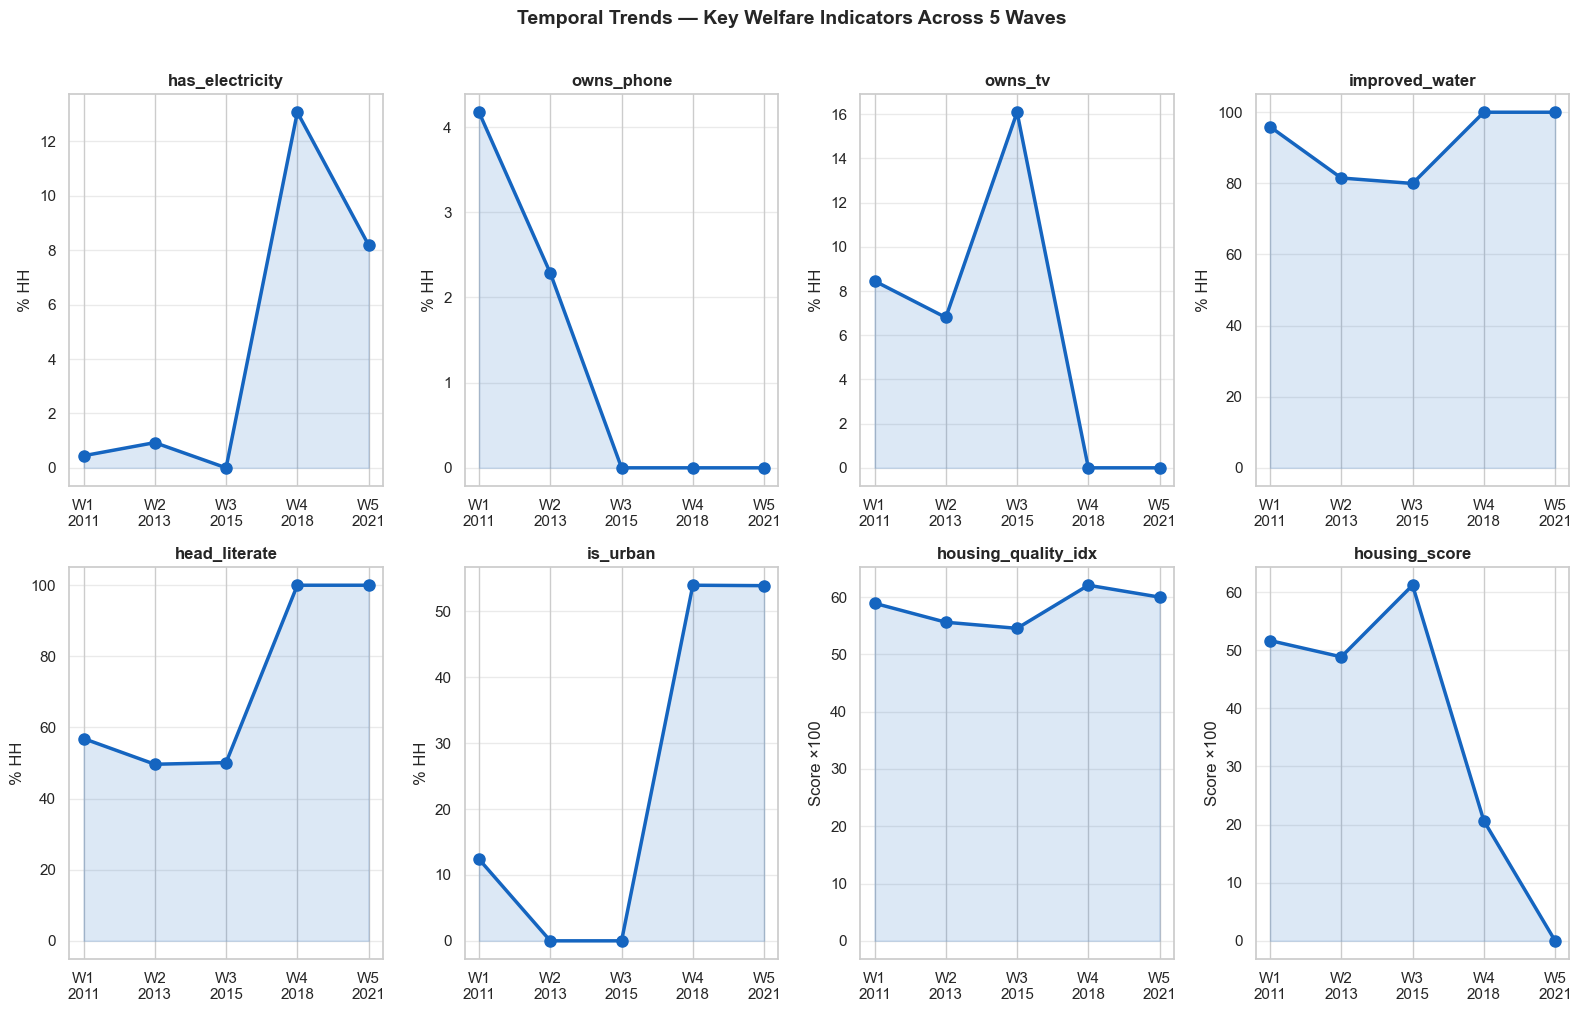

In [12]:
trend_cols = ['has_electricity','owns_phone','owns_tv','improved_water',
              'head_literate','is_urban','housing_quality_idx','housing_score']
trend_cols = [c for c in trend_cols if c in df.columns]

wave_labels = {1:'W1\n2011', 2:'W2\n2013', 3:'W3\n2015',
               4:'W4\n2018', 5:'W5\n2021'}

trend = df.groupby('wave')[trend_cols].mean().multiply(100)

n_cols = 4
n_rows = -(-len(trend_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows))
axes = axes.ravel()

for i, col in enumerate(trend_cols):
    ax = axes[i]
    y = trend[col] if col in ['housing_quality_idx','housing_score'] else trend[col]
    ax.plot(trend.index, y, 'o-', color='#1565c0', lw=2.5, ms=8)
    ax.fill_between(trend.index, y, alpha=0.15, color='#1565c0')
    ax.set_xticks(trend.index)
    ax.set_xticklabels([wave_labels.get(w,'') for w in trend.index])
    ax.set_title(col, fontweight='bold')
    ax.set_ylabel('% HH' if col not in ('housing_quality_idx','housing_score') else 'Score ×100')
    ax.grid(axis='y', alpha=0.4)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Temporal Trends — Key Welfare Indicators Across 5 Waves',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../reports/temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Outlier Detection - IQR & Z-Score
IQR-based outlier detection, We apply it here to all continuous features, per wave.


In [ ]:
# IQR outlier detection
outlier_report = cleaner.detect_outliers(
    df,
    cols=['head_age','rooms','hh_n_workers','housing_score','n_shocks',
          'enterprise_asset_count','hh_avg_weeks_worked','assets_per_member'],
    multiplier=3.0
)
print(f"Outlier summary (IQR × 3.0 per wave):")
print(outlier_report.to_string(index=False))


Outlier summary (IQR × 3.0 per wave):
            feature  wave  n_outliers  lower_bound  upper_bound
hh_avg_weeks_worked     2         147      -40.500       54.000
hh_avg_weeks_worked     4         681    -1064.000     1463.000
hh_avg_weeks_worked     5         394    -2324.000     3143.000
  assets_per_member     1         859        0.000        0.000
  assets_per_member     2         839        0.000        0.000
  assets_per_member     3        1028        0.000        0.000


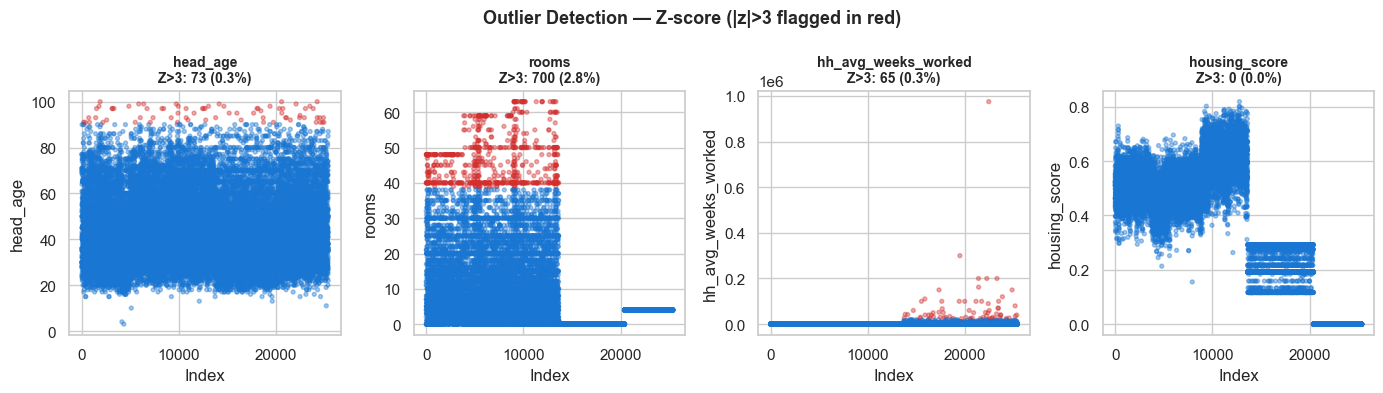

In [ ]:
# Z-score outlier check 
from scipy.stats import zscore

zcols = ['head_age','rooms','hh_avg_weeks_worked','housing_score']
zcols = [c for c in zcols if c in df.columns]

fig, axes = plt.subplots(1, len(zcols), figsize=(14, 4))
for ax, col in zip(axes, zcols):
    data = df[col].dropna()
    zs   = np.abs(zscore(data))
    ax.scatter(range(len(data)), data, c=['#d32f2f' if z>3 else '#1976D2'
               for z in zs], alpha=0.4, s=8)
    ax.set_title(f'{col}\nZ>3: {int((zs>3).sum())} ({(zs>3).mean()*100:.1f}%)',
                 fontsize=10, fontweight='bold')
    ax.set_ylabel(col); ax.set_xlabel('Index')

plt.suptitle('Outlier Detection - Z-score (|z|>3 flagged in red)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/outlier_detection.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Shock Exposure Analysis

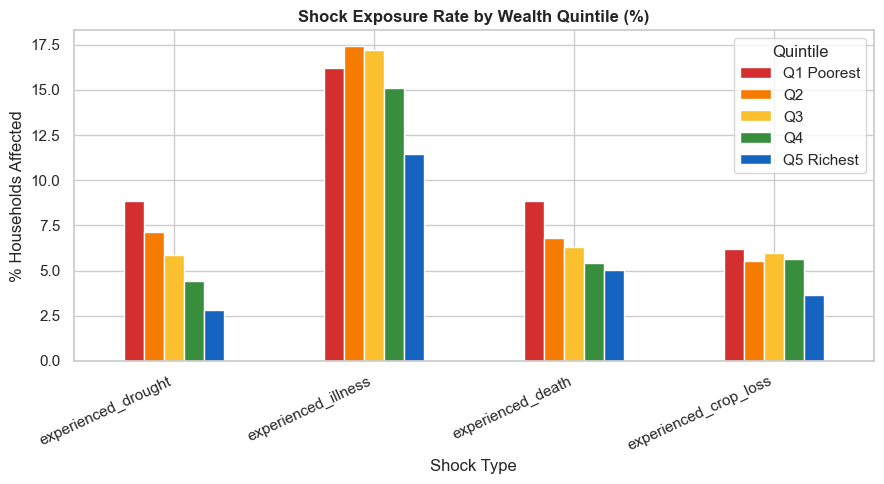

In [15]:
shock_cols = ['experienced_drought','experienced_illness',
              'experienced_death','experienced_crop_loss']
shock_cols = [c for c in shock_cols if c in df.columns]

if not shock_cols:
    print('No shock columns are available in the current dataset.')
else:
    shock_by_q = (df.groupby('cons_quint')[shock_cols]
                    .mean().multiply(100))

    fig, ax = plt.subplots(figsize=(9, 5))
    shock_by_q.T.plot(kind='bar', ax=ax, color=COLORS5, edgecolor='white')
    ax.set_title('Shock Exposure Rate by Wealth Quintile (%)', fontweight='bold')
    ax.set_xlabel('Shock Type'); ax.set_ylabel('% Households Affected')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
    ax.legend(title='Quintile', labels=[Q_LABELS[i] for i in range(1,6)])
    plt.tight_layout()
    plt.savefig('../reports/shock_by_quintile.png', dpi=150, bbox_inches='tight')
    plt.show()


## 12. Hypothesis Testing - Statistical Inference
Hypothesis testing to confirm EDA findings statistically.

In [16]:
from scipy.stats import mannwhitneyu, chi2_contingency, kruskal

print("=" * 65)
print("HYPOTHESIS TESTS (α = 0.05)")
print("=" * 65)

# Test 1: Urban vs Rural — Mean Quintile (Mann-Whitney U)
if 'settlement' in df.columns:
    urban  = df.loc[df['settlement']==0, 'cons_quint'].dropna()
    rural  = df.loc[df['settlement']==1, 'cons_quint'].dropna()
    stat, p = mannwhitneyu(urban, rural, alternative='greater')
    print(f"\n1. Urban vs Rural wealth (Mann-Whitney U)")
    print(f"   H0: Urban quintile ≤ Rural quintile")
    print(f"   Urban mean={urban.mean():.3f} | Rural mean={rural.mean():.3f}")
    print(f"   Statistic={stat:.0f}  p={p:.4f}  → {'REJECT H0 ✓' if p<0.05 else 'Fail to reject H0'}")

# Test 2: Electricity access × wealth quintile (Chi-square)
if 'has_electricity' in df.columns:
    ct = pd.crosstab(df['has_electricity'].fillna(0).astype(int),
                     df['cons_quint'])
    chi2, p2, dof, _ = chi2_contingency(ct)
    print(f"\n2. Electricity access × Wealth quintile (Chi-square)")
    print(f"   H0: Electricity access is independent of wealth quintile")
    print(f"   χ²={chi2:.2f}  df={dof}  p={p2:.4f}  → {'REJECT H0 ✓' if p2<0.05 else 'Fail to reject H0'}")

# Test 3: Kruskal-Wallis — housing_score across quintiles
if 'housing_score' in df.columns:
    groups = [df.loc[df['cons_quint']==q,'housing_score'].dropna() for q in range(1,6)]
    stat3, p3 = kruskal(*groups)
    print(f"\n3. Housing score across quintiles (Kruskal-Wallis)")
    print(f"   H0: Housing score distribution is equal across all quintiles")
    print(f"   H={stat3:.2f}  p={p3:.6f}  → {'REJECT H0 ✓' if p3<0.05 else 'Fail to reject H0'}")
    median_by_q = df.groupby('cons_quint')['housing_score'].median()
    print(f"   Median by quintile: {dict(median_by_q.round(3))}")

print("\n" + "="*65)


HYPOTHESIS TESTS (α = 0.05)

1. Urban vs Rural wealth (Mann-Whitney U)
   H0: Urban quintile ≤ Rural quintile
   Urban mean=3.932 | Rural mean=2.919
   Statistic=71751597  p=0.0000  → REJECT H0 ✓

2. Electricity access × Wealth quintile (Chi-square)
   H0: Electricity access is independent of wealth quintile
   χ²=159.05  df=4  p=0.0000  → REJECT H0 ✓

3. Housing score across quintiles (Kruskal-Wallis)
   H0: Housing score distribution is equal across all quintiles
   H=70.55  p=0.000000  → REJECT H0 ✓
   Median by quintile: {1.0: np.float64(0.442), 2.0: np.float64(0.444), 3.0: np.float64(0.435), 4.0: np.float64(0.402), 5.0: np.float64(0.38)}

